In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [98]:
sns.set_style("darkgrid")

In [99]:
dataset_limpo_medianag = pd.read_csv("./DATASET/dataset_limpo_medianag.csv")
dataset_limpo_medianag.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Code,Geração
0,1,I am a developer by profession,<18,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,Sem dado,...,10.0,5.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,1,Gen Alpha
1,2,I am a developer by profession,35-44,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,Sem dado,Sem dado,65000.0,7.0,4,Millennials/Gen X
2,3,I am a developer by profession,45-54,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,10.0,5.0,0.0,0.0,Appropriate in length,Easy,65000.0,7.0,5,Gen X
3,4,I am learning to code,18-24,"Student, full-time",Sem dado,Apples,Sem dado,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,10.0,5.0,0.0,0.0,Too long,Easy,65000.0,7.0,2,Gen Z
4,5,I am a developer by profession,18-24,"Student, full-time",Sem dado,Apples,Sem dado,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,10.0,5.0,0.0,0.0,Too short,Easy,65000.0,7.0,2,Gen Z


In [100]:
dataset_limpo_medianag["YearsCode"] = dataset_limpo_medianag["YearsCode"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_limpo_medianag["YearsCode"] = pd.to_numeric(dataset_limpo_medianag["YearsCode"])

dataset_limpo_medianag["YearsCodePro"] = dataset_limpo_medianag["YearsCodePro"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_limpo_medianag["YearsCodePro"] = pd.to_numeric(dataset_limpo_medianag["YearsCodePro"])

In [101]:
data = dataset_limpo_medianag.select_dtypes(include="number")

data_plot = data[
    (data["ConvertedCompYearly"] > 1000) &
    (data["ConvertedCompYearly"] < 500000)
].copy()

data.columns

Index(['ResponseId', 'YearsCode', 'YearsCodePro', 'CompTotal', 'WorkExp',
       'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
       'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Code'],
      dtype='object')

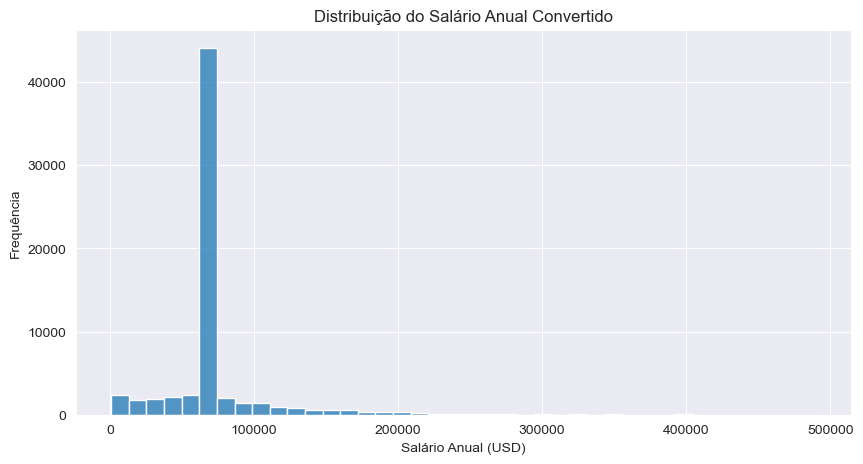

In [102]:
plt.figure(figsize=(10, 5))
sns.histplot(data_plot["ConvertedCompYearly"], bins=40)
plt.title("Distribuição do Salário Anual Convertido")
plt.xlabel("Salário Anual (USD)")
plt.ylabel("Frequência")
plt.show()

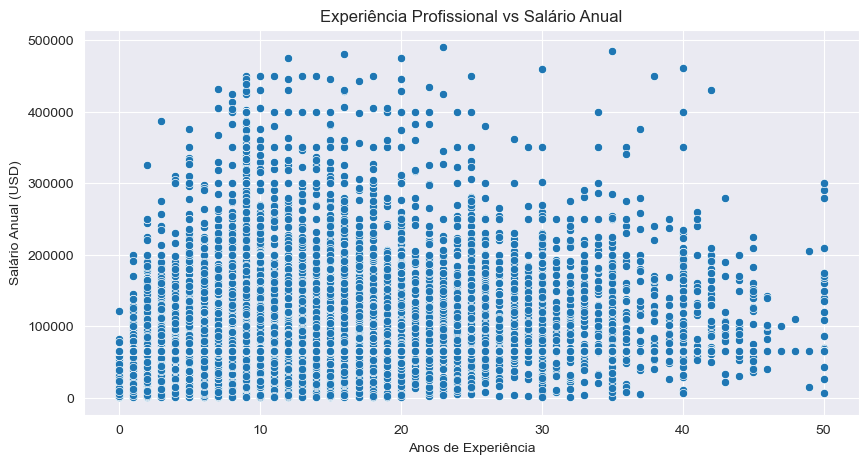

In [103]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data_plot, x="WorkExp", y="ConvertedCompYearly")
plt.title("Experiência Profissional vs Salário Anual")
plt.xlabel("Anos de Experiência")
plt.ylabel("Salário Anual (USD)")
plt.show()

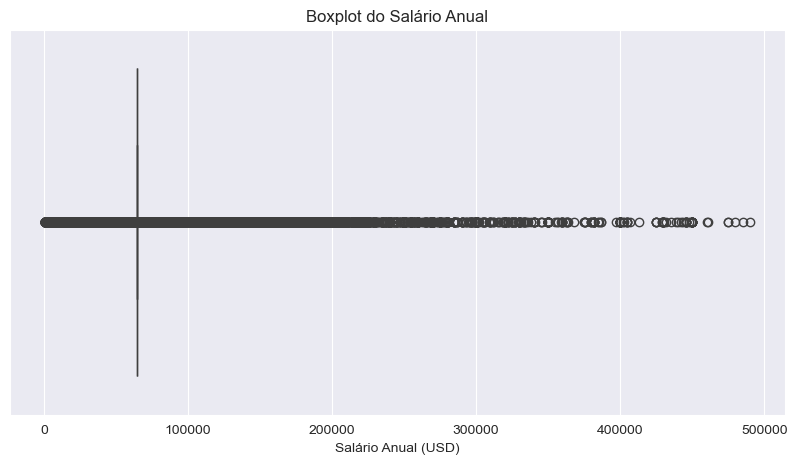

In [104]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=data_plot["ConvertedCompYearly"])
plt.title("Boxplot do Salário Anual")
plt.xlabel("Salário Anual (USD)")
plt.show()

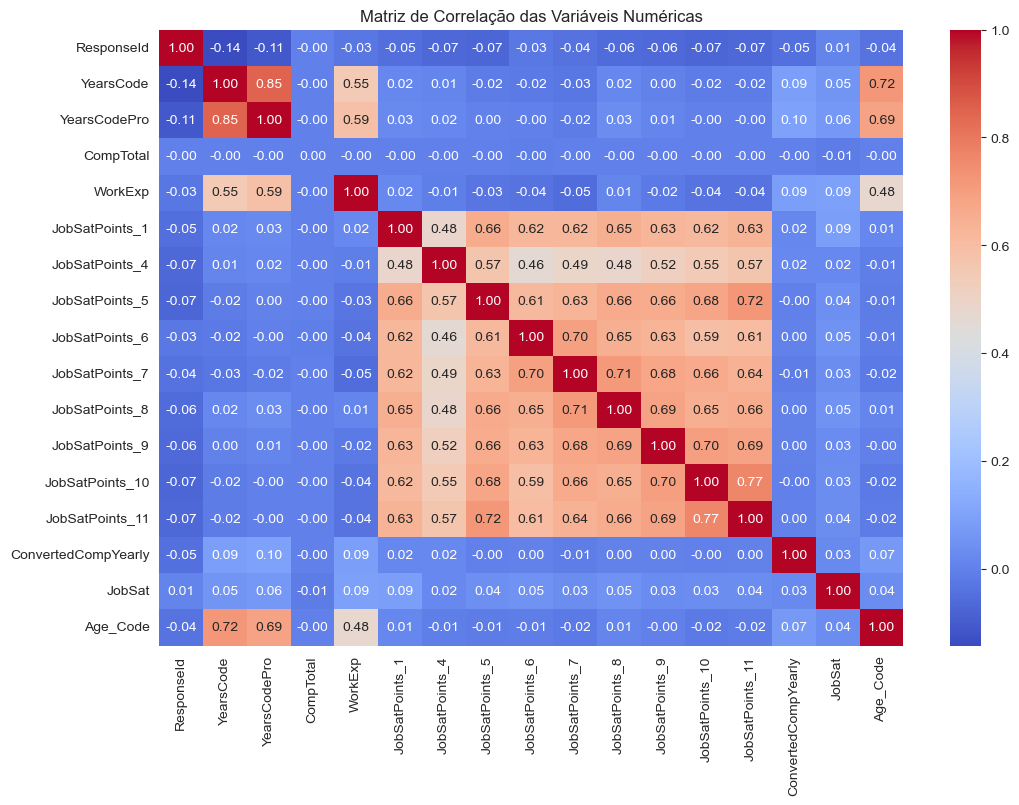

In [105]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

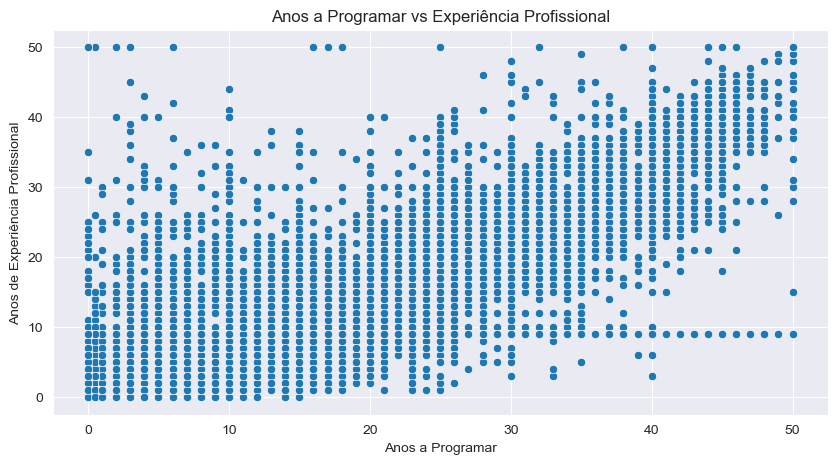

In [106]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="YearsCode", y="WorkExp")
plt.title("Anos a Programar vs Experiência Profissional")
plt.xlabel("Anos a Programar")
plt.ylabel("Anos de Experiência Profissional")
plt.show()

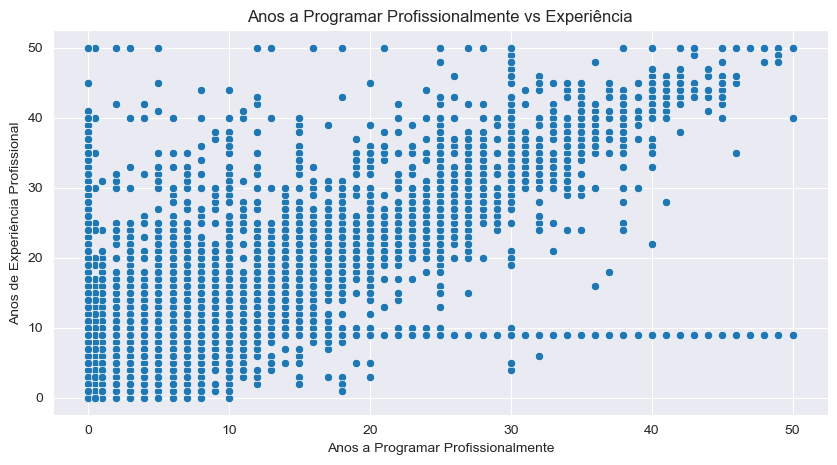

In [107]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="YearsCodePro", y="WorkExp")
plt.title("Anos a Programar Profissionalmente vs Experiência")
plt.xlabel("Anos a Programar Profissionalmente")
plt.ylabel("Anos de Experiência Profissional")
plt.show()

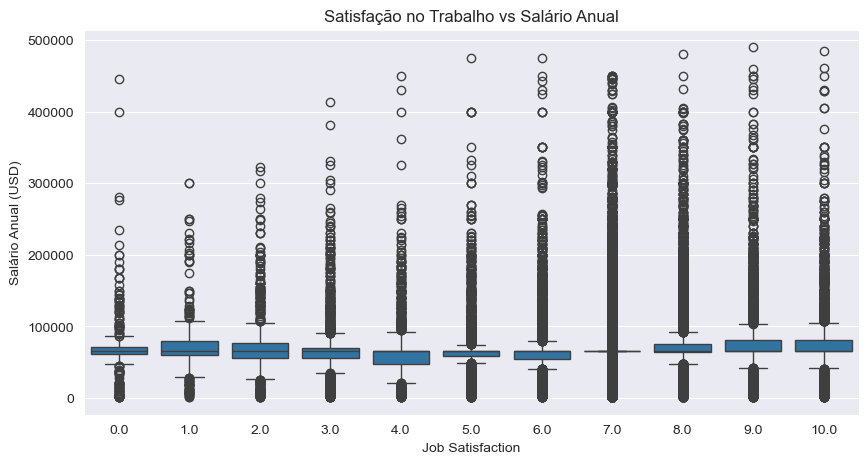

In [108]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Satisfação no Trabalho vs Salário Anual")
plt.xlabel("Job Satisfaction")
plt.ylabel("Salário Anual (USD)")
plt.show()

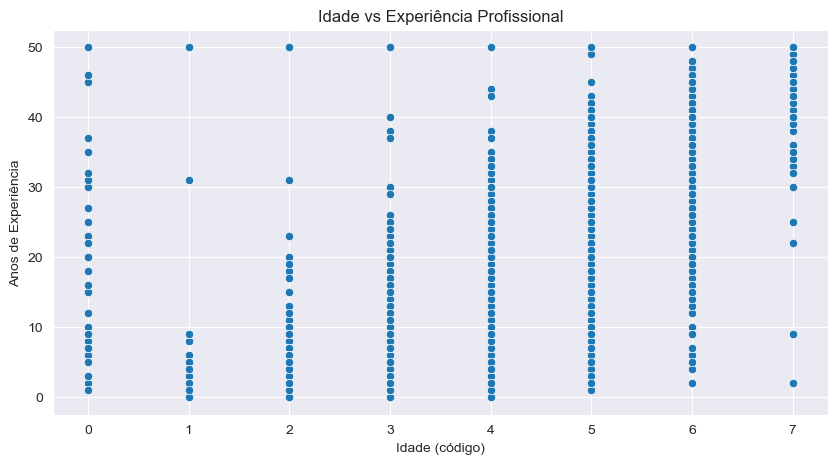

In [109]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x="Age_Code", y="WorkExp")
plt.title("Idade vs Experiência Profissional")
plt.xlabel("Idade (código)")
plt.ylabel("Anos de Experiência")
plt.show()

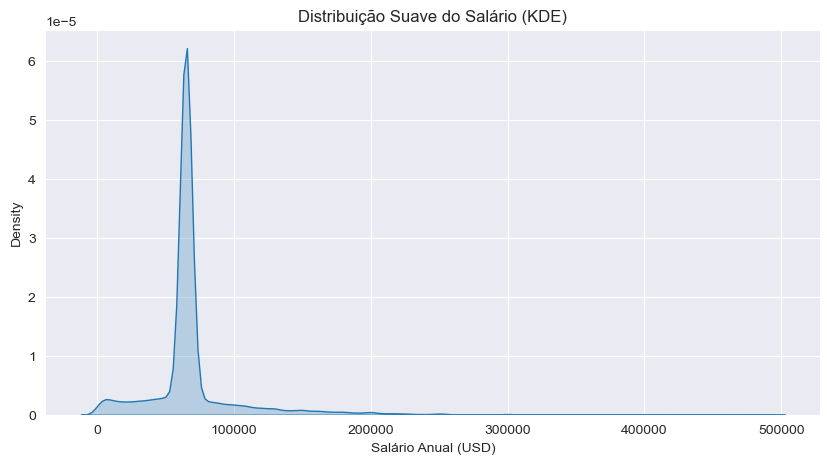

In [110]:
plt.figure(figsize=(10,5))
sns.kdeplot(data_plot["ConvertedCompYearly"], fill=True)
plt.title("Distribuição Suave do Salário (KDE)")
plt.xlabel("Salário Anual (USD)")
plt.show()

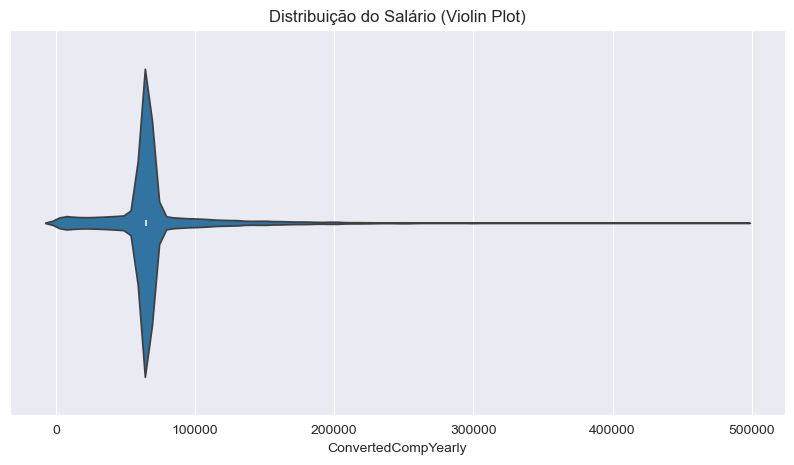

In [111]:
plt.figure(figsize=(10,5))
sns.violinplot(x=data_plot["ConvertedCompYearly"])
plt.title("Distribuição do Salário (Violin Plot)")
plt.show()

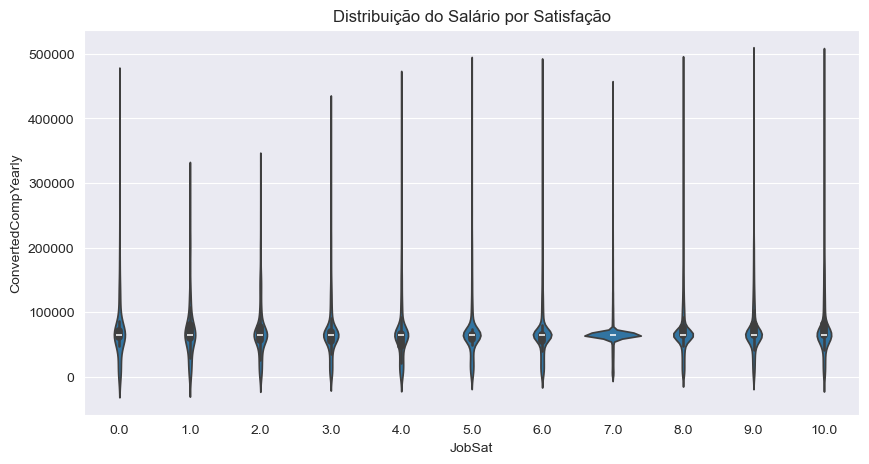

In [112]:
plt.figure(figsize=(10,5))
sns.violinplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Distribuição do Salário por Satisfação")
plt.show()

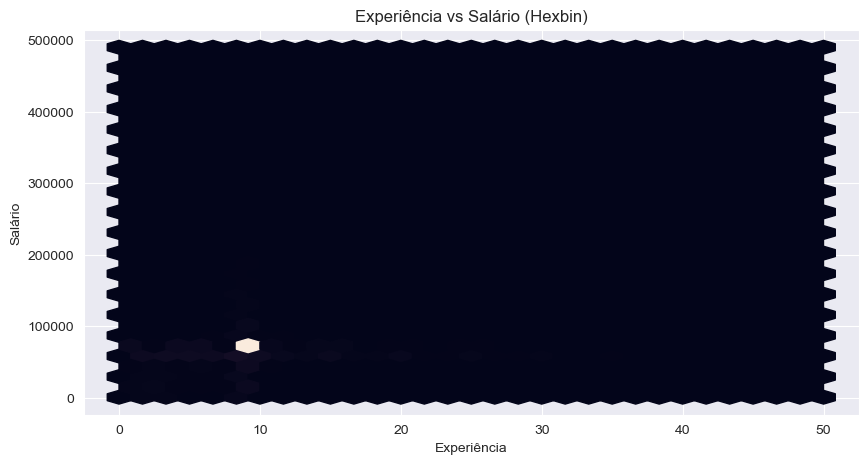

In [113]:
plt.figure(figsize=(10,5))
plt.hexbin(data_plot["WorkExp"], data_plot["ConvertedCompYearly"], gridsize=30)
plt.title("Experiência vs Salário (Hexbin)")
plt.xlabel("Experiência")
plt.ylabel("Salário")
plt.show()

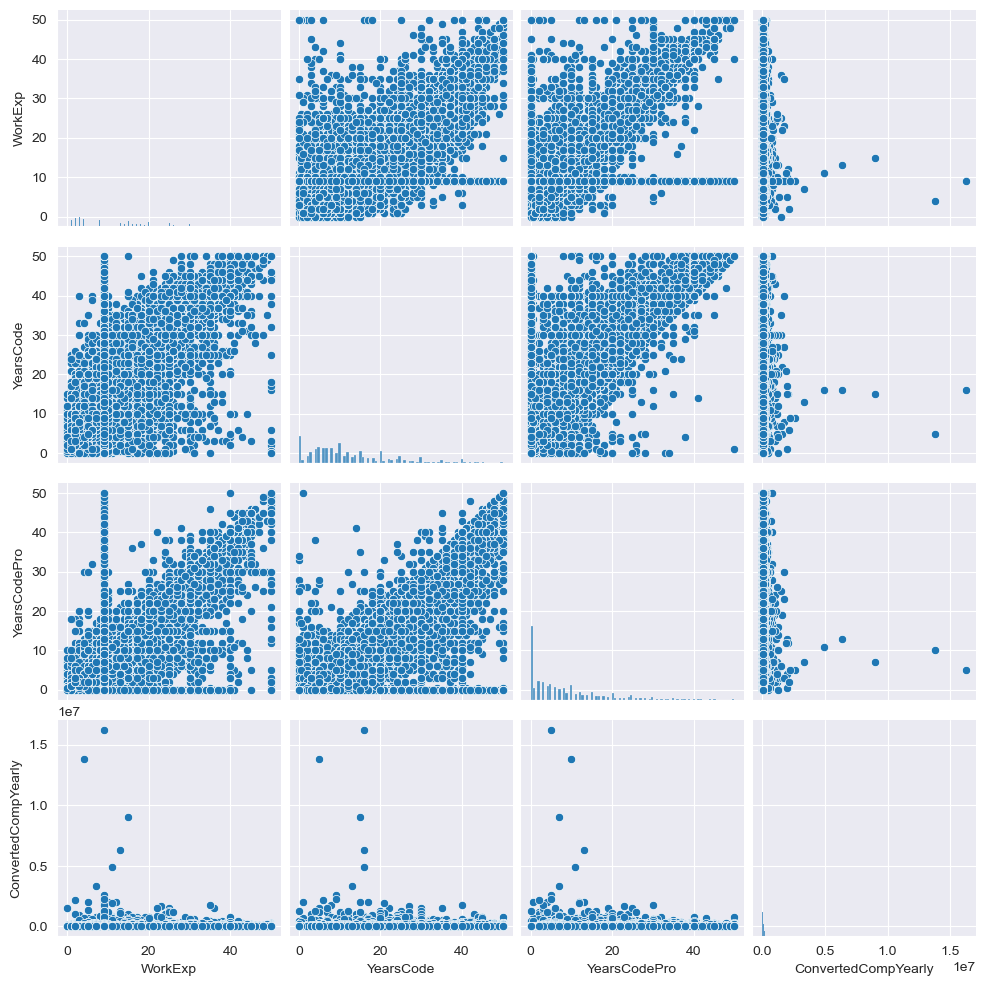

In [114]:
sns.pairplot(data[["WorkExp","YearsCode","YearsCodePro","ConvertedCompYearly"]])
plt.show()

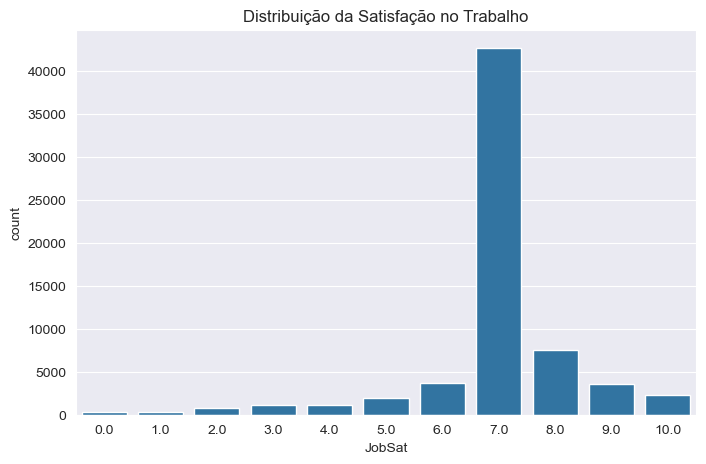

In [115]:
plt.figure(figsize=(8,5))
sns.countplot(x=data["JobSat"])
plt.title("Distribuição da Satisfação no Trabalho")
plt.show()

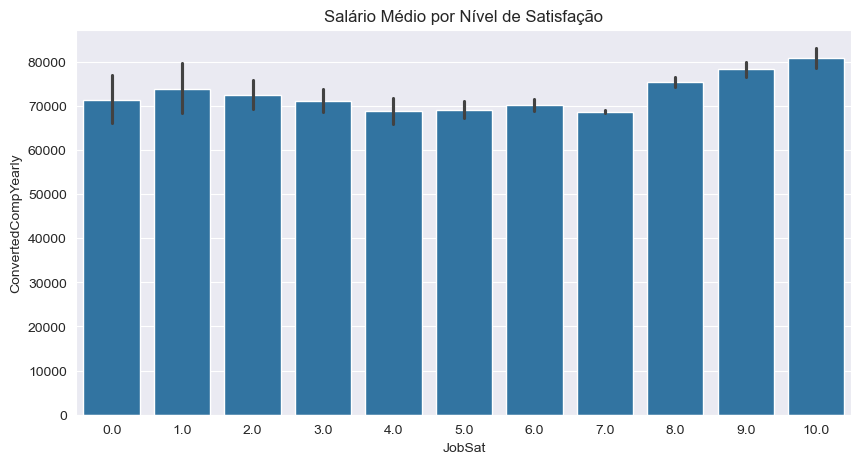

In [116]:
plt.figure(figsize=(10,5))
sns.barplot(data=data_plot, x="JobSat", y="ConvertedCompYearly")
plt.title("Salário Médio por Nível de Satisfação")
plt.show()

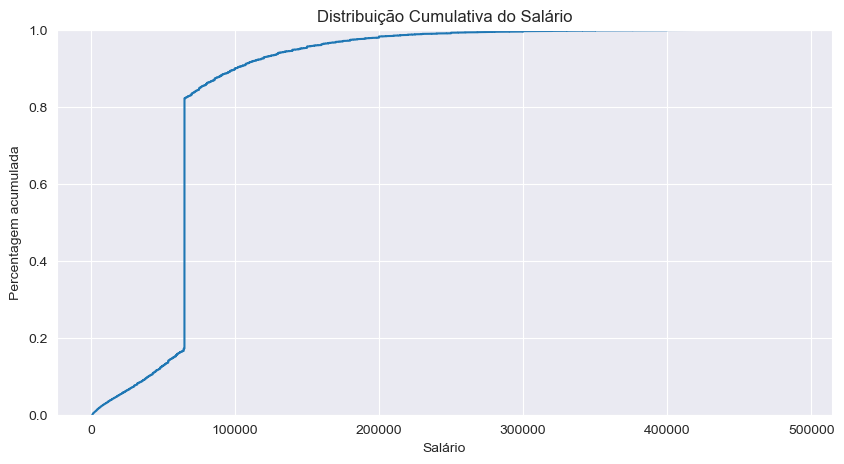

In [117]:
plt.figure(figsize=(10,5))
sns.ecdfplot(data_plot["ConvertedCompYearly"])
plt.title("Distribuição Cumulativa do Salário")
plt.xlabel("Salário")
plt.ylabel("Percentagem acumulada")
plt.show()

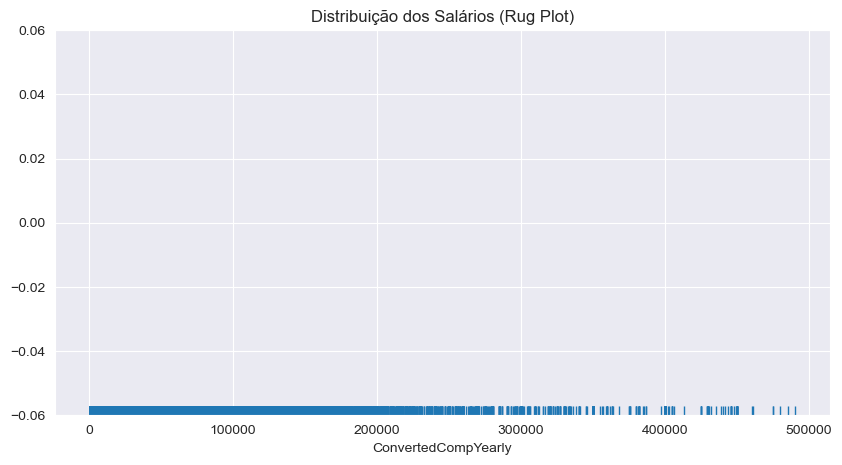

In [118]:
plt.figure(figsize=(10,5))
sns.rugplot(data_plot["ConvertedCompYearly"])
plt.title("Distribuição dos Salários (Rug Plot)")
plt.show()

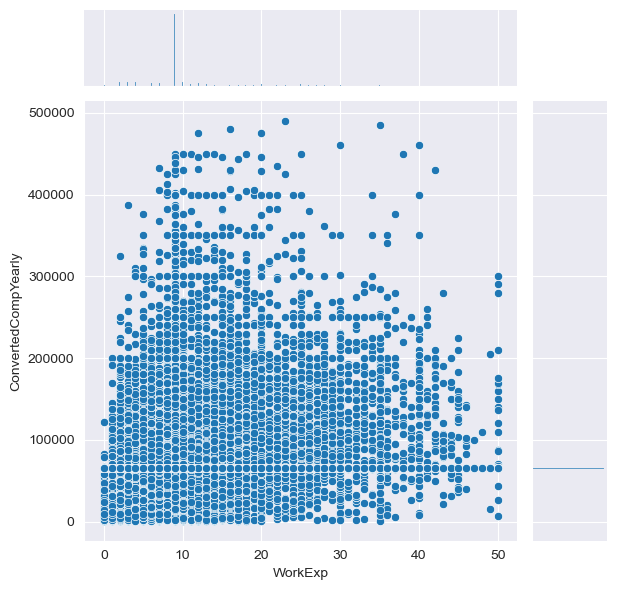

In [119]:
sns.jointplot(data=data_plot, x="WorkExp", y="ConvertedCompYearly", kind="scatter")
plt.show()

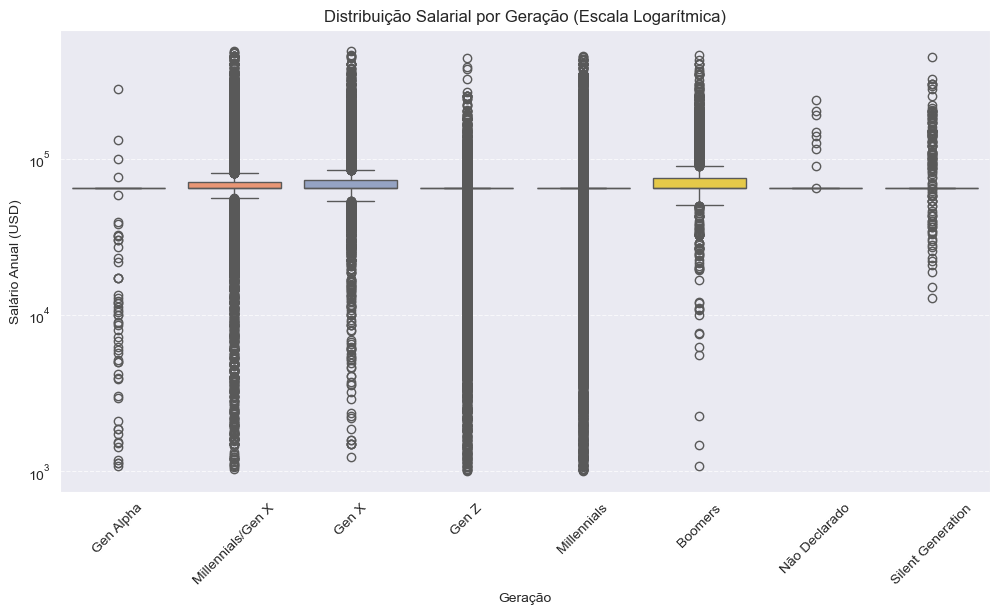

In [120]:
# 1. Filtrar o dataset do colega para excluir valores nulos ou extremos
# Usamos o intervalo de 1.000 a 500.000 para maior clareza visual
df_plot = dataset_limpo_medianag[
    (dataset_limpo_medianag['ConvertedCompYearly'] > 1000) & 
    (dataset_limpo_medianag['ConvertedCompYearly'] < 500000)
].copy()

# 2. Criar o gráfico
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Geração', y='ConvertedCompYearly', hue='Geração', palette='Set2', legend=False)

# 3. Ajustar escala para logarítmica (essencial para dados salariais)
plt.yscale('log') 

plt.title('Distribuição Salarial por Geração (Escala Logarítmica)')
plt.xlabel('Geração')
plt.ylabel('Salário Anual (USD)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

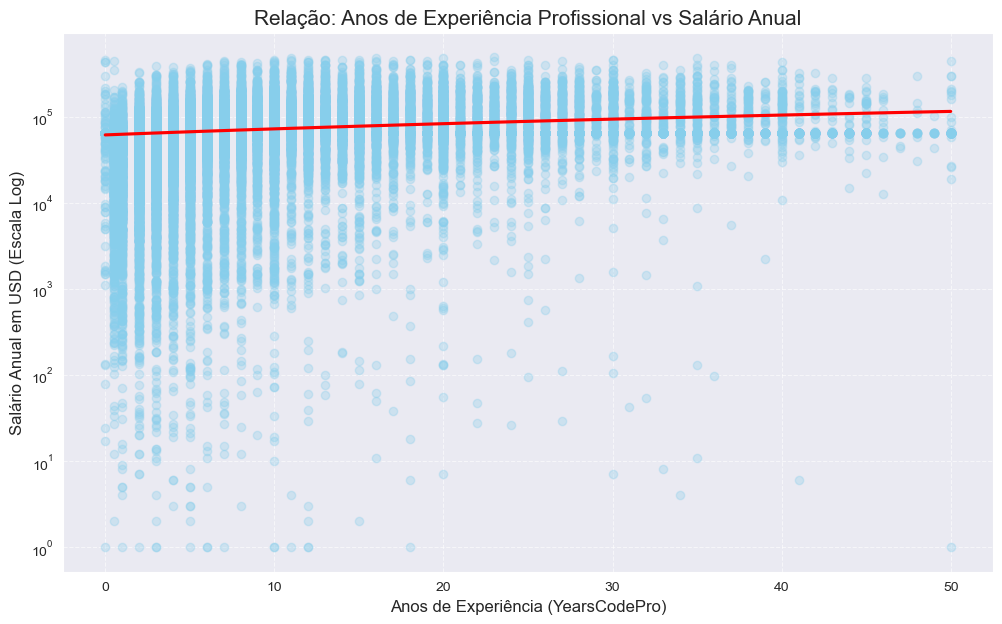

In [121]:
# 1. Preparar os dados (remover nulos nas duas colunas para o gráfico não quebrar)
# Usamos o 'dataset_limpo_medianag' que é o nome correto no teu ficheiro
df_exp_sal = dataset_limpo_medianag.dropna(subset=['YearsCodePro', 'ConvertedCompYearly']).copy()

# Garantir que os anos de experiência são números (caso estejam como texto)
df_exp_sal['YearsCodePro'] = pd.to_numeric(df_exp_sal['YearsCodePro'], errors='coerce')

# 2. Filtrar outliers para o gráfico ser legível (ex: salários até 500k)
df_exp_sal = df_exp_sal[df_exp_sal['ConvertedCompYearly'] < 500000]

# 3. Criar o gráfico de Experiência vs Salário
plt.figure(figsize=(12, 7))

sns.regplot(data=df_exp_sal, 
            x='YearsCodePro', 
            y='ConvertedCompYearly', 
            scatter_kws={'alpha':0.3, 'color':'skyblue'}, 
            line_kws={'color':'red'})

# 4. Ajustes de escala e títulos
plt.yscale('log') # Escala logarítmica no salário para melhor visualização
plt.title('Relação: Anos de Experiência Profissional vs Salário Anual', fontsize=15)
plt.xlabel('Anos de Experiência (YearsCodePro)', fontsize=12)
plt.ylabel('Salário Anual em USD (Escala Log)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

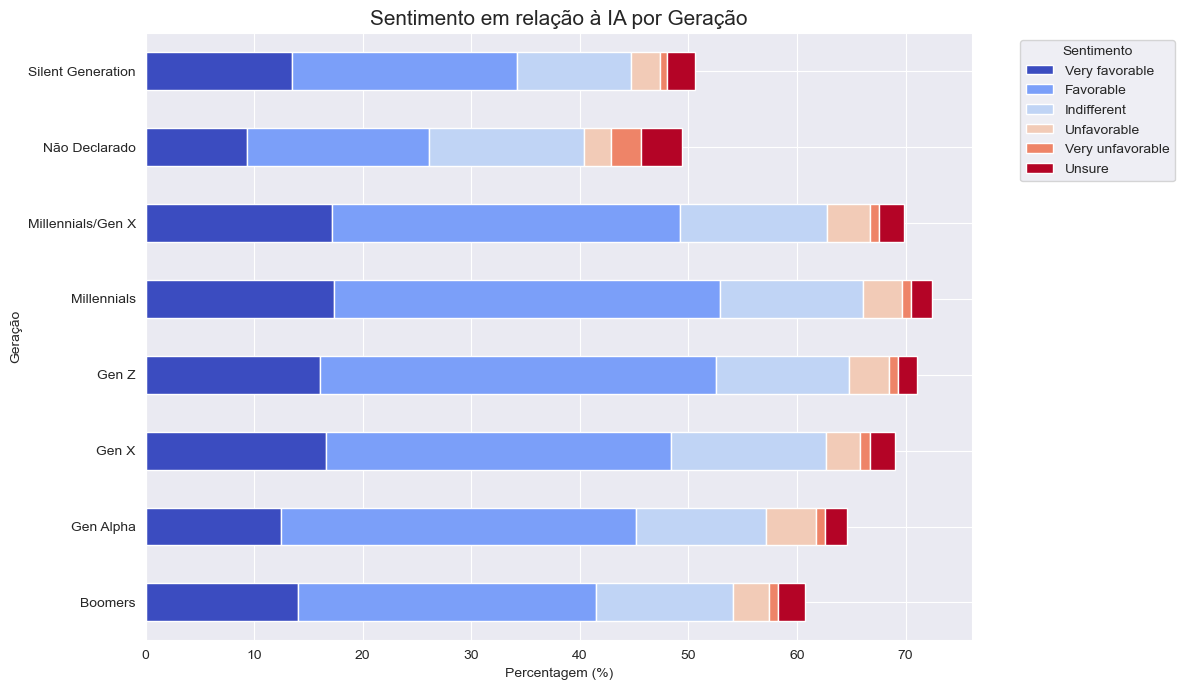

In [122]:
# --- Análise de Sentimento sobre IA por Geração ---

# 1. Limpar dados: Remover quem não respondeu à pergunta sobre IA (AISent)
# Usamos o dataset_limpo_medianag que é o padrão do teu colega
df_ai = dataset_limpo_medianag[dataset_limpo_medianag['AISent'].notnull()].copy()

# 2. Criar uma tabela de cruzamento (Geração vs Sentimento)
# normalize='index' é fundamental para comparar gerações com números de pessoas diferentes
ai_analysis = pd.crosstab(df_ai['Geração'], df_ai['AISent'], normalize='index') * 100

# 3. Ordenar os sentimentos para uma leitura lógica (do mais positivo ao mais negativo)
# Verifiquei as categorias padrão do Stack Overflow
ordem_sentimento = ['Very favorable', 'Favorable', 'Indifferent', 'Unfavorable', 'Very unfavorable', 'Unsure']
# Filtramos apenas as que existem no teu dataset para evitar erros
ordem_existente = [sent for sent in ordem_sentimento if sent in ai_analysis.columns]
ai_analysis = ai_analysis.reindex(columns=ordem_existente)

# 4. Desenhar o gráfico de barras empilhadas (Stacked Bar Chart)
ai_analysis.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='coolwarm')

plt.title('Sentimento em relação à IA por Geração', fontsize=15)
plt.xlabel('Percentagem (%)')
plt.ylabel('Geração')
# Coloca a legenda fora do gráfico para não tapar as barras
plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

--- Percentagem de Uso de IA por Geração ---
AISelect           No, and I don't plan to  No, but I plan to soon  Sem dado  \
Geração                                                                        
Boomers                              35.69                   21.36      3.50   
Gen Alpha                            27.06                    9.15      7.87   
Gen X                                26.88                   18.63      3.95   
Gen Z                                18.85                    7.92      9.57   
Millennials                          19.89                   12.02      7.32   
Millennials/Gen X                    24.49                   15.26      5.47   
Não Declarado                        36.02                   11.80     13.98   
Silent Generation                    45.60                   19.69      3.63   

AISelect             Yes  
Geração                   
Boomers            39.46  
Gen Alpha          55.92  
Gen X              50.54  
Gen Z              

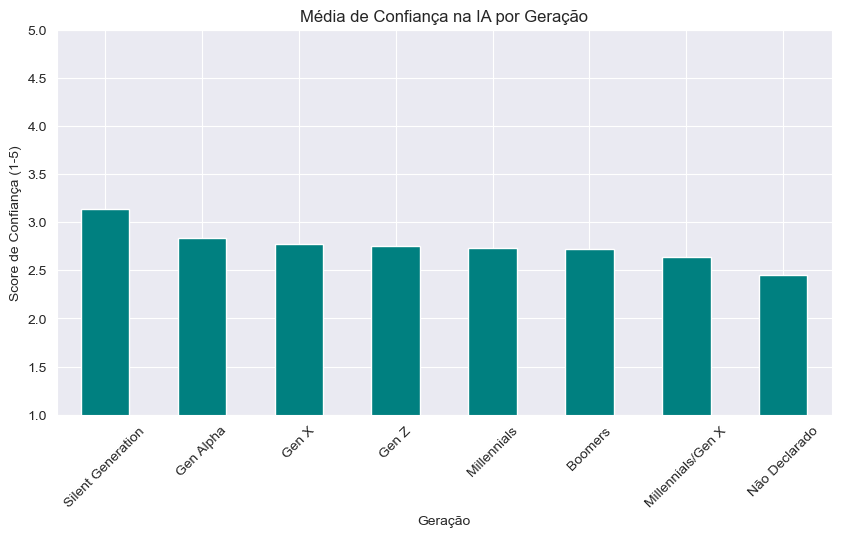

In [123]:
# --- Análise de Uso e Confiança na IA por Geração ---

# 1. Percentagem de Uso de IA por Geração
# Usamos 'dataset_limpo_medianag'
uso_ia = pd.crosstab(dataset_limpo_medianag['Geração'], dataset_limpo_medianag['AISelect'], normalize='index') * 100

# 2. Criar um Score Numérico para a Confiança (AIAcc)
# Isto permite calcular uma média (ex: a Gen Z confia 4.2 em 5)
confianca_map = {
    'Highly trust': 5,
    'Trust': 4,
    'Neither trust nor distrust': 3,
    'Distrust': 2,
    'Highly distrust': 1
}

# Criamos a nova coluna no dataset do colega
dataset_limpo_medianag['AI_Trust_Score'] = dataset_limpo_medianag['AIAcc'].map(confianca_map)

# Calcular a média por geração
confianca_gen = dataset_limpo_medianag.groupby('Geração')['AI_Trust_Score'].mean().sort_values(ascending=False)

# 3. Exibir os resultados
print("--- Percentagem de Uso de IA por Geração ---")
print(uso_ia.round(2)) # round(2) para não ter demasiadas casas decimais
print("\n--- Média de Confiança na IA (Escala 1-5) ---")
print(confianca_gen.round(2))

# --- BÓNUS: Gráfico rápido de Confiança ---
plt.figure(figsize=(10, 5))
confianca_gen.plot(kind='bar', color='teal')
plt.title('Média de Confiança na IA por Geração')
plt.ylabel('Score de Confiança (1-5)')
plt.ylim(1, 5) # A escala vai de 1 a 5
plt.xticks(rotation=45)
plt.show()

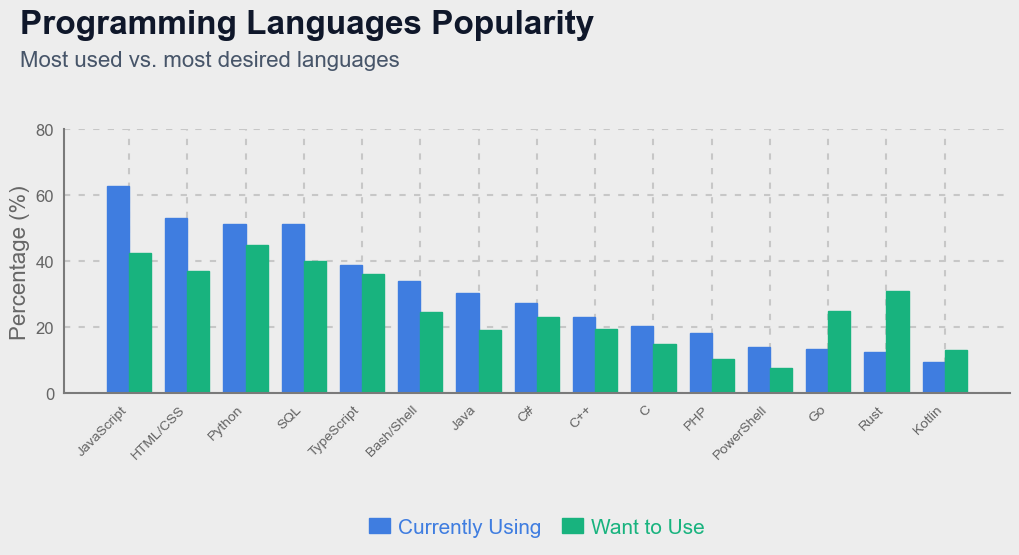

Total de linguagens mostradas: 15
Most Popular Language: JavaScript (62.75% usage rate)


In [124]:
# --- Programming Languages Popularity (Top 15) | visual estilo referência ---

col_uso = 'LanguageHaveWorkedWith'
col_desejo = 'LanguageWantToWorkWith'

def split_langs(series):
    serie_limpa = series.dropna()
    serie_limpa = serie_limpa[serie_limpa != 'Sem dado']
    langs = serie_limpa.astype(str).str.split(';').explode().str.strip()
    return langs[langs != '']

uso_explodido = split_langs(dataset_limpo_medianag[col_uso])
desejo_explodido = split_langs(dataset_limpo_medianag[col_desejo])

base_uso = dataset_limpo_medianag[col_uso].notna() & (dataset_limpo_medianag[col_uso] != 'Sem dado')
base_desejo = dataset_limpo_medianag[col_desejo].notna() & (dataset_limpo_medianag[col_desejo] != 'Sem dado')

n_uso = int(base_uso.sum())
n_desejo = int(base_desejo.sum())

pct_uso = (uso_explodido.value_counts() / n_uso * 100)
pct_desejo = (desejo_explodido.value_counts() / n_desejo * 100)

# Top 15 por uso atual
top15_langs = pct_uso.head(15).index
lang_df_top15 = pd.DataFrame({
    'Currently Using': pct_uso.reindex(top15_langs, fill_value=0),
    'Want to Use': pct_desejo.reindex(top15_langs, fill_value=0)
})

# Labels mais limpos
lang_df_top15.index = lang_df_top15.index.str.replace('Bash/Shell (all shells)', 'Bash/Shell', regex=False)

# Cores e layout no estilo da imagem
color_using = '#3f7de0'
color_want = '#18b37e'
card_bg = '#ededed'
grid_color = '#c7c7c7'
text_dark = '#0f172a'
text_mid = '#475569'

fig, ax = plt.subplots(figsize=(11, 6), facecolor=card_bg)
ax.set_facecolor(card_bg)

x = np.arange(len(lang_df_top15.index))
bar_width = 0.38

ax.bar(x - bar_width / 2, lang_df_top15['Currently Using'].values, width=bar_width, color=color_using, edgecolor=color_using, label='Currently Using')
ax.bar(x + bar_width / 2, lang_df_top15['Want to Use'].values, width=bar_width, color=color_want, edgecolor=color_want, label='Want to Use')

# Título e subtítulo
fig.text(0.06, 0.93, 'Programming Languages Popularity', fontsize=24, fontweight='bold', color=text_dark)
fig.text(0.06, 0.875, 'Most used vs. most desired languages', fontsize=16, color=text_mid)

# Eixos
ax.set_ylabel('Percentage (%)', fontsize=16, color='#666666')
ax.set_xticks(x)
ax.set_xticklabels(lang_df_top15.index, rotation=45, ha='right', fontsize=10, color='#666666')
ax.tick_params(axis='y', labelsize=12, colors='#666666')

# Escala e grid
max_y = max(lang_df_top15.max())
y_max = max(80, int(np.ceil(max_y / 10.0) * 10) + 10)
ax.set_ylim(0, y_max)
ax.grid(True, axis='both', linestyle=(0, (3, 4)), linewidth=1.5, color=grid_color)
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#7a7a7a')
ax.spines['bottom'].set_color('#7a7a7a')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Legenda em baixo, centrada
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.40), ncol=2, frameon=False, fontsize=15, handlelength=1.0, handletextpad=0.4, columnspacing=1.0)
legend_texts = legend.get_texts()
if len(legend_texts) >= 2:
    legend_texts[0].set_color(color_using)
    legend_texts[1].set_color(color_want)

plt.subplots_adjust(top=0.77, left=0.10, right=0.96, bottom=0.33)
plt.show()

print('Total de linguagens mostradas:', len(lang_df_top15))
mais_popular = pct_uso.index[0]
mais_popular_pct = pct_uso.iloc[0]
print(f"Most Popular Language: {mais_popular} ({mais_popular_pct:.2f}% usage rate)")

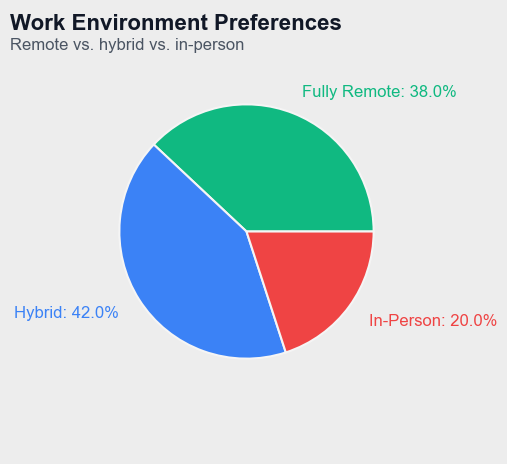

RemoteWork
Fully Remote    38.0%
Hybrid          42.0%
In-Person       20.0%


In [182]:

# Mapeamento para rótulos mais curtos e claros
from matplotlib.pyplot import axis


map_remote = {
    'Remote': 'Fully Remote',
    'Hybrid (some remote, some in-person)': 'Hybrid',
    'In-person': 'In-Person'
}

# Usa dados reais do dataset e remove respostas sem informação
remote_counts = (
    dataset_limpo_medianag['RemoteWork']
    .dropna()
    .loc[lambda s: s != 'Sem dado']
    .map(map_remote)
    .value_counts()
    .reindex(['Fully Remote', 'Hybrid', 'In-Person'])
    .dropna()
)

remote_pct = remote_counts / remote_counts.sum() * 100

# Cores no mesmo espírito da imagem
colors = ['#10b981', '#3b82f6', '#ef4444']

# Quadro um pouco menor e com menos espaço vazio no topo
fig, ax = plt.subplots(figsize=(5.5, 5), facecolor='#ededed')
ax.set_facecolor('#ededed')

wedges, _ = ax.pie(
    remote_pct.values,
    colors=colors,
    startangle=0,
    radius=0.8,
    wedgeprops={'edgecolor': '#f5f5f5', 'linewidth': 1.5}
)

# Labels externos coloridos como na referência
for i, w in enumerate(wedges):
    ang = (w.theta2 + w.theta1) / 2
    x = 0.95 * np.cos(np.deg2rad(ang))
    y = 0.95 * np.sin(np.deg2rad(ang))

    label = f"{remote_pct.index[i]}: {remote_pct.iloc[i]:.1f}%"
    ha = 'left' if x >= 0 else 'right'

    ax.text(
        x,
        y,
        label,
        color=colors[i],
        fontsize=12,
        fontweight='medium',
        ha=ha,
        va='center'
    )

# Título e subtítulo mais próximos do gráfico
fig.text(0.07, 0.90, 'Work Environment Preferences', fontsize=16, fontweight='bold', color='#111827')
fig.text(0.07, 0.86, 'Remote vs. hybrid vs. in-person', fontsize=12, color='#4b5563')

ax.set(aspect='equal')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_position([0.08, 0.08, 0.84, 0.68])
plt.subplots_adjust(top=0.94, left=0.04, right=0.96, bottom=0.05)
plt.show()

print((remote_pct.round(1).astype(str) + '%').to_string())

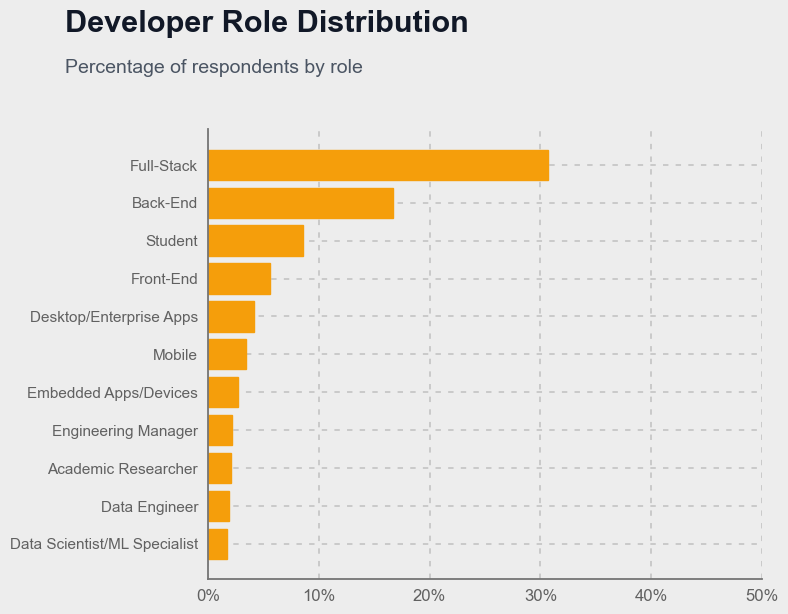

Base de respondentes com DevType válido: 59445
Tipos únicos reais em DevType: 34
Categorias excluídas: Other (please specify):

Top 11 Dev Types (%):
                                         Role  Percent
                        Developer, full-stack  30.7175
                          Developer, back-end  16.7012
                                      Student   8.5827
                         Developer, front-end   5.6338
Developer, desktop or enterprise applications   4.1938
                            Developer, mobile   3.3998
  Developer, embedded applications or devices   2.7303
                          Engineering manager   2.1448
                          Academic researcher   2.0826
                                Data engineer   1.8807
Data scientist or machine learning specialist   1.7226


In [184]:
# --- Developer Role Distribution (Top 11 com Student) ---

import os

# Base de respondentes com DevType válido
roles_raw = dataset_limpo_medianag['DevType'].dropna().astype(str)
roles_raw = roles_raw[roles_raw != 'Sem dado']
den = len(roles_raw)

# DevType é multi-resposta; separar cada tipo
dev_items = roles_raw.str.split(';').explode().str.strip()
dev_items = dev_items[dev_items != '']

# Excluir apenas a categoria genérica 'Other'
exclude_roles = ['Other (please specify):']
dev_items_filtered = dev_items[~dev_items.isin(exclude_roles)]

# Top 11 tipos reais após exclusão de Other
top11_counts = dev_items_filtered.value_counts().head(11)
top11_pct = (top11_counts / den) * 100

role_df = pd.DataFrame({
    'Role': top11_counts.index,
    'Count': top11_counts.values,
    'Percent': top11_pct.values
}).sort_values('Percent', ascending=True)

# Labels curtos para o eixo Y (evita empurrar o gráfico para a direita)
role_df['RoleLabel'] = (
    role_df['Role']
    .str.replace('Developer, full-stack', 'Full-Stack', regex=False)
    .str.replace('Developer, back-end', 'Back-End', regex=False)
    .str.replace('Developer, front-end', 'Front-End', regex=False)
    .str.replace('Developer, desktop or enterprise applications', 'Desktop/Enterprise Apps', regex=False)
    .str.replace('Developer, mobile', 'Mobile', regex=False)
    .str.replace('Developer, embedded applications or devices', 'Embedded Apps/Devices', regex=False)
    .str.replace('Data scientist or machine learning specialist', 'Data Scientist/ML Specialist', regex=False)
    .str.replace('Engineering manager', 'Engineering Manager', regex=False)
    .str.replace('Academic researcher', 'Academic Researcher', regex=False)
    .str.replace('Data engineer', 'Data Engineer', regex=False)
    .str.replace('Student', 'Student', regex=False)
)

# Estilo visual inspirado na imagem
fig, ax = plt.subplots(figsize=(8.4, 7.5), facecolor='#ededed')
ax.set_facecolor('#ededed')

ax.barh(role_df['RoleLabel'], role_df['Percent'], color='#f59e0b', edgecolor='#f59e0b')

# Título e subtítulo mais compactos
fig.text(0.07, 0.90, 'Developer Role Distribution', fontsize=22, fontweight='bold', color='#111827')
fig.text(0.07, 0.845, 'Percentage of respondents by role', fontsize=14, color='#4b5563')

ax.set_xlim(0, max(50, role_df['Percent'].max() * 1.12))
ax.set_xticks([0, 10, 20, 30, 40, 50])
ax.set_xticklabels(['0%', '10%', '20%', '30%', '40%', '50%'], fontsize=12, color='#616161')
ax.tick_params(axis='y', labelsize=11, colors='#616161')

ax.grid(True, axis='both', linestyle=(0, (3, 4)), linewidth=1.3, color='#c7c7c7')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#757575')
ax.spines['bottom'].set_color('#757575')
ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

# Sobe o gráfico para reduzir o espaço branco entre subtítulo e barras
ax.set_position([0.24, 0.17, 0.66, 0.60])
plt.show()

# Guardar validação na pasta Validations
validation_df = role_df[['Role', 'Count', 'Percent']].copy()
validation_df = validation_df.sort_values('Percent', ascending=False)
validation_df['Percent'] = validation_df['Percent'].round(4)
validation_df['BaseValidDevType'] = den
validation_df['ExcludedRoles'] = ', '.join(exclude_roles)
validation_df['BaseTotalDataset'] = len(dataset_limpo_medianag)
validation_df['Rule'] = 'Top 11 categorias reais de DevType (multi-resposta), incluindo Student e excluindo Other'

output_dir = './Validations'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'dev_role_distribution_top11_with_student_validation.csv')
validation_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print('Base de respondentes com DevType válido:', den)
print('Tipos únicos reais em DevType:', dev_items.nunique())
print('Categorias excluídas:', ', '.join(exclude_roles))
print('\nTop 11 Dev Types (%):')
print(validation_df[['Role', 'Percent']].to_string(index=False))

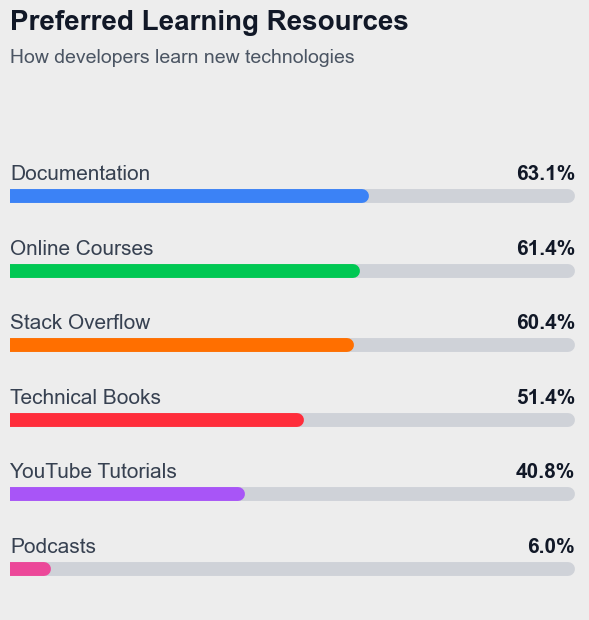

Base total usada (sem exclusão): 65437
Documentation: 63.1% (41267)
Online Courses: 61.4% (40183)
Stack Overflow: 60.4% (39492)
Technical Books: 51.4% (33633)
YouTube Tutorials: 40.8% (26668)
Podcasts: 6.0% (3955)


In [136]:
# --- Preferred Learning Resources (valores reais, sem exclusão de linhas) ---

import os
import re

if 'dataset_limpo_medianag' not in globals():
    dataset_limpo_medianag = pd.read_csv('./DATASET/dataset_limpo_medianag.csv')

df_learn = dataset_limpo_medianag[['LearnCode', 'LearnCodeOnline']].copy()

# Base total do dataset, sem excluir respostas
n_total = len(df_learn)

# Junta as duas colunas em texto único por linha
learn_text = (
    df_learn['LearnCode'].fillna('') + ';' + df_learn['LearnCodeOnline'].fillna('')
).astype(str)

resources = {
    'Online Courses': [
        'Online Courses or Certification',
        'Video-based Online Courses',
        'Written-based Online Courses',
        'Certification videos'
    ],
    'Documentation': ['Technical documentation'],
    'Stack Overflow': ['Stack Overflow'],
    'YouTube Tutorials': ['How-to videos'],
    'Technical Books': ['Books / Physical media', 'Books'],
    'Podcasts': ['Auditory material (e.g., podcasts)']
}

perc = {}
counts = {}
for name, vals in resources.items():
    escaped = [re.escape(v) for v in vals]
    pattern = '|'.join(escaped)
    mask = learn_text.str.contains(pattern, regex=True)
    counts[name] = int(mask.sum())
    perc[name] = mask.mean() * 100

order = [
    'Documentation',
    'Online Courses',
    'Stack Overflow',
    'Technical Books',
    'YouTube Tutorials',
    'Podcasts'
]

palette = ['#3b82f6', '#00c853', '#ff6f00', '#ff2d3b', '#a855f7', '#ec4899']

# Layout mais compacto (gráfico e fontes menores)
fig, ax = plt.subplots(figsize=(6.4, 6.6), facecolor='#ededed')
ax.set_facecolor('#ededed')

y_positions = list(range(len(order), 0, -1))

for yi, name, color in zip(y_positions, order, palette):
    val = perc[name]
    # Barra de fundo
    ax.hlines(yi, 0, 100, color='#cfd2d8', linewidth=10, capstyle='round')
    # Barra de valor
    ax.hlines(yi, 0, val, color=color, linewidth=10, capstyle='round')
    # Rótulo da categoria
    ax.text(0, yi + 0.30, name, ha='left', va='center', fontsize=15, color='#374151')
    # Percentual à direita
    ax.text(101.2, yi + 0.30, f'{val:.1f}%', ha='right', va='center', fontsize=15, fontweight='bold', color='#111827')

fig.text(0.06, 0.94, 'Preferred Learning Resources', fontsize=20, fontweight='bold', color='#111827')
fig.text(0.06, 0.89, 'How developers learn new technologies', fontsize=14, color='#4b5563')

ax.set_xlim(0, 102)
ax.set_ylim(0.45, len(order) + 1.0)
ax.axis('off')

plt.subplots_adjust(top=0.80, left=0.06, right=0.95, bottom=0.06)
plt.show()

# Guardar validação na pasta Validations
validation_df = pd.DataFrame({
    'Resource': order,
    'Count': [counts[name] for name in order],
    'Percentage': [round(perc[name], 4) for name in order],
    'BaseTotal': [n_total] * len(order),
    'Rule': ['Sem exclusao de linhas do dataset'] * len(order)
})

output_dir = './Validations'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'preferred_learning_resources_validation.csv')
validation_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f'Base total usada (sem exclusão): {n_total}')
for name in order:
    print(f'{name}: {perc[name]:.1f}% ({counts[name]})')

In [160]:
# --- KPI 1: Total Respondents (apenas cálculo e print) ---

df_kpi = dataset_limpo_medianag.copy()

if 'ResponseId' in df_kpi.columns:
    total_respondents = int(df_kpi['ResponseId'].dropna().nunique())
    calc_total = 'nunique(ResponseId sem nulos)'
else:
    total_respondents = int(len(df_kpi))
    calc_total = 'len(dataset)'

print('KPI: Total Respondents')
print(f'Valor: {total_respondents:,}')
print(f'Regra: {calc_total}')

KPI: Total Respondents
Valor: 65,437
Regra: nunique(ResponseId sem nulos)


In [161]:
# --- KPI 2: Countries Represented (apenas cálculo e print) ---

df_kpi = dataset_limpo_medianag.copy()

if 'Country' in df_kpi.columns:
    valid_country = df_kpi['Country'].dropna()
    valid_country = valid_country[valid_country != 'Sem dado']
    countries_represented = int(valid_country.nunique())
    calc_countries = "nunique(Country) após remover nulos e 'Sem dado'"
else:
    countries_represented = None
    calc_countries = 'Coluna Country não encontrada'

display_value = countries_represented if countries_represented is not None else 'N/A'

print('KPI: Countries Represented')
print(f'Valor: {display_value}')
print(f'Regra: {calc_countries}')

KPI: Countries Represented
Valor: 185
Regra: nunique(Country) após remover nulos e 'Sem dado'


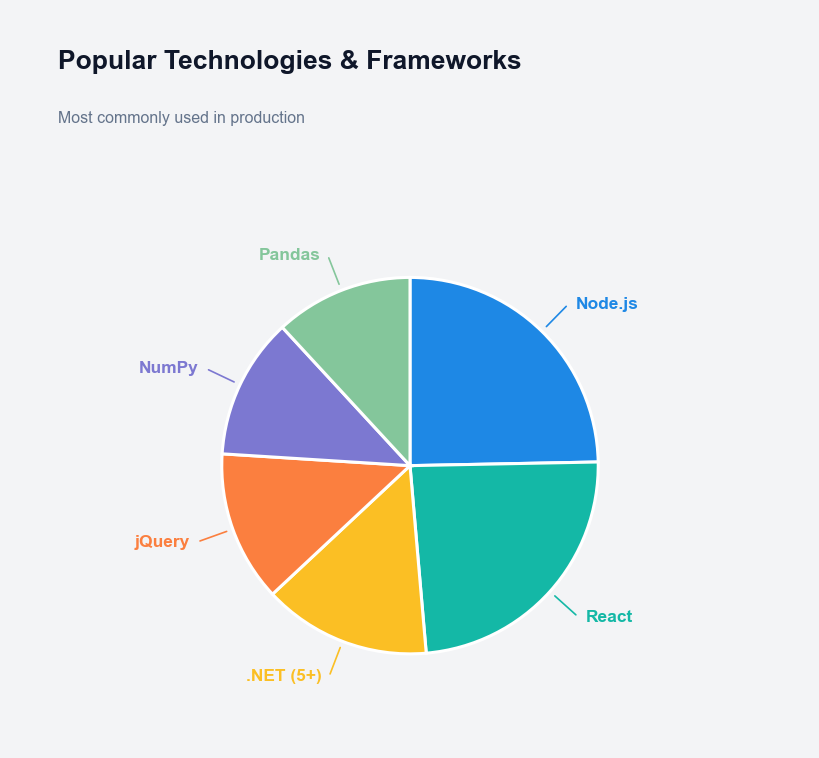

Base total do dataset: 65437
Colunas usadas: WebframeHaveWorkedWith, MiscTechHaveWorkedWith
Total de opções validadas: 75

Top 6 (% real):
Technology  Percent
   Node.js  30.2153
     React  29.2908
 .NET (5+)  17.6383
    jQuery  15.8641
     NumPy  14.8509
    Pandas  14.5193


In [192]:
df_tf = dataset_limpo_medianag.copy()
base_total = len(df_tf)
 
candidate_cols = [
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith'
]
tech_cols = [c for c in candidate_cols if c in df_tf.columns]
if not tech_cols:
    raise ValueError('Nenhuma coluna de web frameworks/technologies foi encontrada no dataset.')
 
counts_by_tech = {}
for _, row in df_tf[tech_cols].fillna('').iterrows():
    per_respondent = set()
    for col in tech_cols:
        raw_value = str(row[col])
        for item in raw_value.split(';'):
            tech = item.strip()
            if tech and tech != 'Sem dado':
                per_respondent.add(tech)
    for tech in per_respondent:
        counts_by_tech[tech] = counts_by_tech.get(tech, 0) + 1
 
all_counts = pd.Series(counts_by_tech).sort_values(ascending=False)
all_pct = (all_counts / base_total) * 100
 

label_map = {
    'Node.js': 'Node.js',
    'React': 'React',
    'Angular': 'Angular',
    'Vue.js': 'Vue.js',
    'jQuery': 'jQuery',
    'ASP.NET CORE': 'ASP.NET Core'
}
plot_df['Label'] = plot_df['Technology'].map(label_map).fillna(plot_df['Technology'])
 
# ── Estilo limpo ──────────────────────────────────────────────────────────────
card_bg    = '#f3f4f6'
title_dark = '#0f172a'
sub_color  = '#64748b'
colors     = ['#1e88e5', '#14b8a6', '#fbbf24', '#fb7f3f', '#7c78d1', '#84c69b']
 
fig = plt.figure(figsize=(8, 8), facecolor=card_bg)
 
# Área do título: faixa estreita no topo
ax_title = fig.add_axes([0.0, 0.82, 1.0, 0.18])
ax_title.set_facecolor(card_bg)
ax_title.axis('off')
ax_title.text(0.06, 0.72, 'Popular Technologies & Frameworks',
              fontsize=19, fontweight='bold', color=title_dark,
              transform=ax_title.transAxes, va='top')
ax_title.text(0.06, 0.30, 'Most commonly used in production',
              fontsize=11.5, color=sub_color,
              transform=ax_title.transAxes, va='top')
 
# Área da pizza: ocupa o resto (centrada, maior)
ax = fig.add_axes([0.10, 0.04, 0.80, 0.78])
ax.set_facecolor(card_bg)
ax.set_aspect('equal')
 
wedges, _ = ax.pie(
    plot_df['Percent'].values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.0,
    wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2.2}
)
 
# Rótulos com linha-guia limpa (pychart-style)
for i, w in enumerate(wedges):
    ang = np.deg2rad((w.theta2 + w.theta1) / 2)
    # ponto na borda da fatia
    x0, y0 = 1.02 * np.cos(ang), 1.02 * np.sin(ang)
    # ponto exterior do líder
    x1, y1 = 1.20 * np.cos(ang), 1.20 * np.sin(ang)
    ha = 'left' if x1 >= 0 else 'right'
    # pequena linha líder
    ax.annotate(
        '',
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle='-', color=colors[i], lw=1.2)
    )
    # rótulo
    x_text = x1 + (0.04 if ha == 'left' else -0.04)
    ax.text(x_text, y1, plot_df['Label'].iloc[i],
            ha=ha, va='center',
            fontsize=12.5, fontweight='600',
            color=colors[i])
 
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.5, 1.5)
 
plt.savefig('./popular_technologies_chart.png', dpi=150,
            bbox_inches='tight', facecolor=card_bg)
plt.show()
 
print('Base total do dataset:', base_total)
print('Colunas usadas:', ', '.join(tech_cols))
print('Total de opções validadas:', len(validation_all_df))
print('\nTop 6 (% real):')
print(plot_df[['Technology', 'Percent']].to_string(index=False))

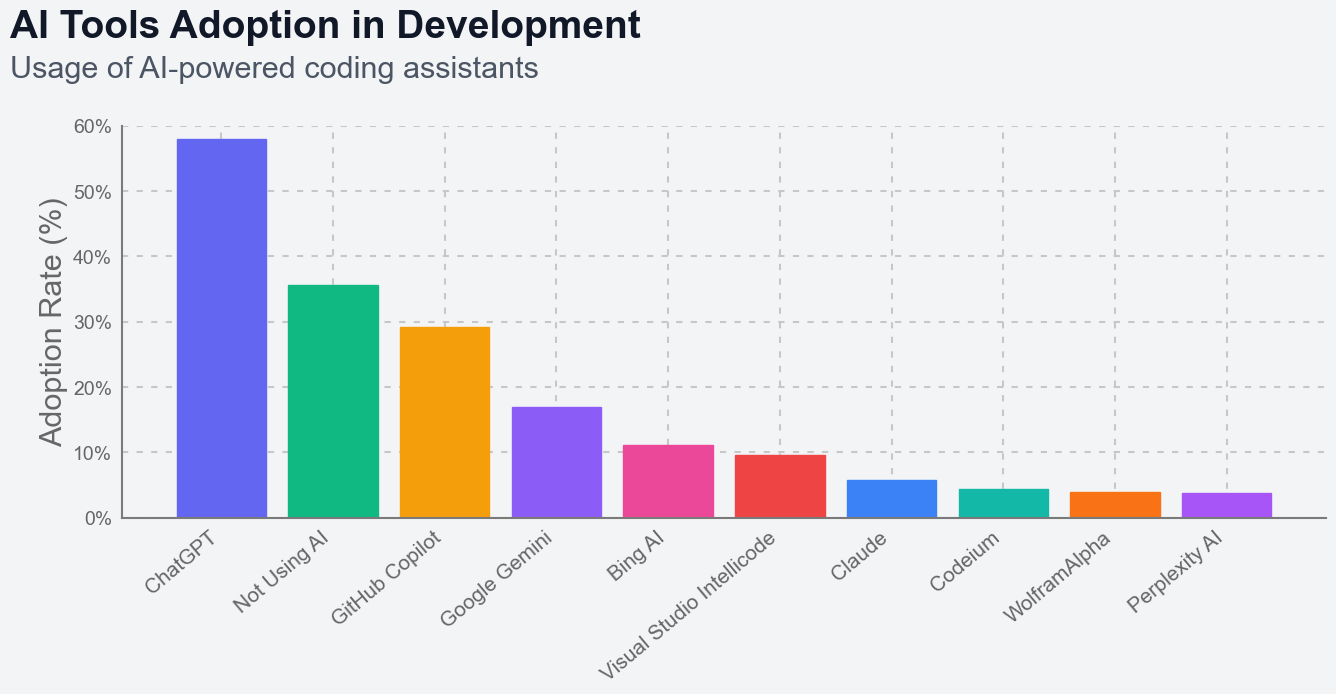

Base total do dataset: 65437
Total de opções validadas (CSV): 26
Total de opções mostradas no gráfico: 10

Top 10 opções (%):
                   Option  Percent
                  ChatGPT  57.9535
             Not Using AI  35.5227
           GitHub Copilot  29.0845
            Google Gemini  16.8956
                  Bing AI  11.1634
Visual Studio Intellicode   9.6215
                   Claude   5.7460
                  Codeium   4.2927
             WolframAlpha   3.9229
            Perplexity AI   3.7624


In [ ]:
# --- AI Tools Adoption in Development (Top 10 no gráfico + validação completa) ---

import os

df_ai_tools = dataset_limpo_medianag.copy()
base_total = len(df_ai_tools)

tools_col = 'AISearchDevHaveWorkedWith'
select_col = 'AISelect'

if tools_col not in df_ai_tools.columns or select_col not in df_ai_tools.columns:
    raise ValueError('Colunas de IA necessárias não encontradas no dataset.')

# Conta adoção de TODAS as ferramentas listadas em AISearchDevHaveWorkedWith
counts_by_tool = {}
for raw in df_ai_tools[tools_col].fillna('').astype(str):
    if raw.strip() == '' or raw.strip() == 'Sem dado':
        continue
    per_respondent = set()
    for item in raw.split(';'):
        tool = item.strip()
        if tool and tool != 'Sem dado':
            per_respondent.add(tool)
    for tool in per_respondent:
        counts_by_tool[tool] = counts_by_tool.get(tool, 0) + 1

# Adiciona opção "Not Using AI" com base no AISelect (sem excluir linhas)
not_using_mask = (
    df_ai_tools[select_col].fillna('').astype(str).str.startswith('No')
 )
counts_by_tool['Not Using AI'] = int(not_using_mask.sum())

all_counts = pd.Series(counts_by_tool).sort_values(ascending=False)
all_pct = (all_counts / base_total) * 100

validation_ai_tools_df = pd.DataFrame({
    'Option': all_counts.index,
    'Count': all_counts.values,
    'Percent': all_pct.values
})
validation_ai_tools_df['Percent'] = validation_ai_tools_df['Percent'].round(4)
validation_ai_tools_df['BaseTotalDataset'] = base_total
validation_ai_tools_df['ColumnsUsed'] = f'{tools_col} + {select_col}'
validation_ai_tools_df['Rule'] = 'Todas as opções em AISearchDevHaveWorkedWith + Not Using AI agregado de AISelect (No...) sem exclusão de linhas'

# Top 10 para visualização
plot_df = validation_ai_tools_df.head(10).copy()

# Cores no estilo da referência
palette = [
    '#6366f1', '#10b981', '#f59e0b', '#8b5cf6', '#ec4899', '#ef4444',
    '#3b82f6', '#14b8a6', '#f97316', '#a855f7', '#22c55e', '#06b6d4', '#64748b', '#eab308'
 ]
bar_colors = [palette[i % len(palette)] for i in range(len(plot_df))]

# Figura
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#f3f4f6')
ax.set_facecolor('#f3f4f6')

x = np.arange(len(plot_df))
ax.bar(x, plot_df['Percent'].values, color=bar_colors, edgecolor=bar_colors, width=0.8)

# Título e subtítulo no estilo pedido
fig.text(0.03, 0.94, 'AI Tools Adoption in Development', fontsize=28, fontweight='bold', color='#111827')
fig.text(0.03, 0.89, 'Usage of AI-powered coding assistants', fontsize=22, color='#4b5563')

# Eixos
ax.set_ylabel('Adoption Rate (%)', fontsize=22, color='#666666')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Option'], rotation=40, ha='right', fontsize=15, color='#666666')
ax.tick_params(axis='y', labelsize=14, colors='#666666')

# Escala e grelha
y_max = max(20, int(np.ceil(plot_df['Percent'].max() / 10.0) * 10))
ax.set_ylim(0, y_max)
yticks = np.arange(0, y_max + 1, 10)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(v)}%' for v in yticks], fontsize=14, color='#666666')
ax.grid(True, axis='both', linestyle=(0, (3, 4)), linewidth=1.5, color='#c7c7c7')
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#7a7a7a')
ax.spines['bottom'].set_color('#7a7a7a')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.subplots_adjust(top=0.83, left=0.11, right=0.97, bottom=0.34)
plt.show()

# Guardar validação completa
output_dir = './Validations'
os.makedirs(output_dir, exist_ok=True)
output_ai_tools = os.path.join(output_dir, 'ai_tools_adoption_all_options_validation.csv')
validation_ai_tools_df.to_csv(output_ai_tools, index=False, encoding='utf-8-sig')

print('Base total do dataset:', base_total)
print('Total de opções validadas (CSV):', len(validation_ai_tools_df))
print('Total de opções mostradas no gráfico:', len(plot_df))
print('\nTop 10 opções (%):')
print(plot_df[['Option', 'Percent']].to_string(index=False))